# 05 Commodities Macro

**Book:** *Global Macro Trading \u2014 Profiting in a New World Economy*  
**Focus:** Construct a CRB-equivalent commodity proxy from the available futures parquet files and compare it to DXY and inflation expectations.


## Proxy Design

The repo does not contain a direct CRB index series, so this notebook builds a **CRB-equivalent proxy** as the geometric mean of the locally available liquid commodity futures:

- `BZ=F`, `CL=F`, `NG=F` for energy
- `GC=F`, `HG=F`, `SI=F` for metals

This is a practical study proxy rather than a faithful reconstruction of the official CRB methodology.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
STUDY_DIR = REPO_ROOT / "workstation" / "playground" / "studies" / "2026-03-27_global_macro_trading_gliner"
FRED_DIR = REPO_ROOT / "data" / "market_data" / "fred"
PRICES_DIR = REPO_ROOT / "data" / "market_data" / "prices"
START = "2024-02-26"
END = "2026-02-27"
CRB_PROXY_CSV = STUDY_DIR / "05_commodity_proxy_panel.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
def _filter_date(frame: pd.DataFrame, start=START, end=END, date_col="date"):
    out = frame.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    return out[(out[date_col] >= start) & (out[date_col] <= end)]


def load_fred_series(series_ids, start=START, end=END):
    frames = []
    for parquet_file in sorted(FRED_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "series_id" not in df.columns:
            continue
        sub = df[df["series_id"].isin(series_ids)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "series_id"])
    wide = (
        joined.pivot(index="date", columns="series_id", values="value")
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


def load_local_price_series(tickers, start=START, end=END, value_col="close"):
    frames = []
    for parquet_file in sorted(PRICES_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "ticker" not in df.columns or value_col not in df.columns:
            continue
        sub = df[df["ticker"].isin(tickers)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "ticker"])
    wide = (
        joined.pivot(index="date", columns="ticker", values=value_col)
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


In [3]:
commodity_prices = load_local_price_series(["BZ=F", "CL=F", "GC=F", "HG=F", "NG=F", "SI=F"])
macro_prices = load_local_price_series(["DX-Y.NYB", "SPY"])
fred_panel = load_fred_series(["T10YIE"])

business_days = pd.date_range(START, END, freq="B")
commodity_prices = commodity_prices.reindex(business_days).ffill().dropna()
macro_panel = macro_prices.join(fred_panel, how="outer").reindex(business_days).ffill().dropna()

normalized = commodity_prices.divide(commodity_prices.iloc[0])
crb_proxy = np.exp(np.log(normalized).mean(axis=1)).mul(100.0).rename("crb_proxy")
energy_proxy = np.exp(np.log(normalized[["BZ=F", "CL=F", "NG=F"]]).mean(axis=1)).mul(100.0).rename("energy_proxy")
metals_proxy = np.exp(np.log(normalized[["GC=F", "HG=F", "SI=F"]]).mean(axis=1)).mul(100.0).rename("metals_proxy")

proxy_panel = pd.concat([crb_proxy, energy_proxy, metals_proxy, macro_panel], axis=1).dropna()
proxy_panel.index.name = "date"
proxy_panel.tail()


             crb_proxy  energy_proxy  metals_proxy   DX-Y.NYB         SPY  T10YIE
date                                                                             
2026-02-23  164.518347    110.032302    245.984915  97.699997  682.390015    2.26
2026-02-24  164.047080    108.424484    248.204496  97.879997  687.349976    2.26
2026-02-25  166.098975    109.014480    253.075275  97.699997  693.150024    2.28
2026-02-26  163.104673    107.082739    248.435320  97.790001  689.299988    2.28
2026-02-27  168.611888    109.825076    258.865917  97.646004  685.989990    2.25

In [4]:
proxy_panel["crb_ret"] = np.log(proxy_panel["crb_proxy"]).diff()
proxy_panel["dxy_ret"] = np.log(proxy_panel["DX-Y.NYB"]).diff()
proxy_panel["spy_ret"] = np.log(proxy_panel["SPY"]).diff()
proxy_panel["breakeven_chg"] = proxy_panel["T10YIE"].diff()
analysis_panel = proxy_panel.dropna().copy()

macro_corr = analysis_panel[["crb_ret", "dxy_ret", "spy_ret", "breakeven_chg"]].corr().round(3)
component_total_return_pct = (normalized.iloc[-1] - 1.0).mul(100.0).round(2).rename("total_return_pct")

print(macro_corr.to_string())
component_total_return_pct.to_frame()


               crb_ret  dxy_ret  spy_ret  breakeven_chg
crb_ret          1.000   -0.121    0.217          0.203
dxy_ret         -0.121    1.000    0.069          0.338
spy_ret          0.217    0.069    1.000          0.286
breakeven_chg    0.203    0.338    0.286          1.000


        total_return_pct
ticker                  
BZ=F              -11.32
CL=F              -13.26
GC=F              161.10
HG=F               58.50
NG=F               72.21
SI=F              319.17

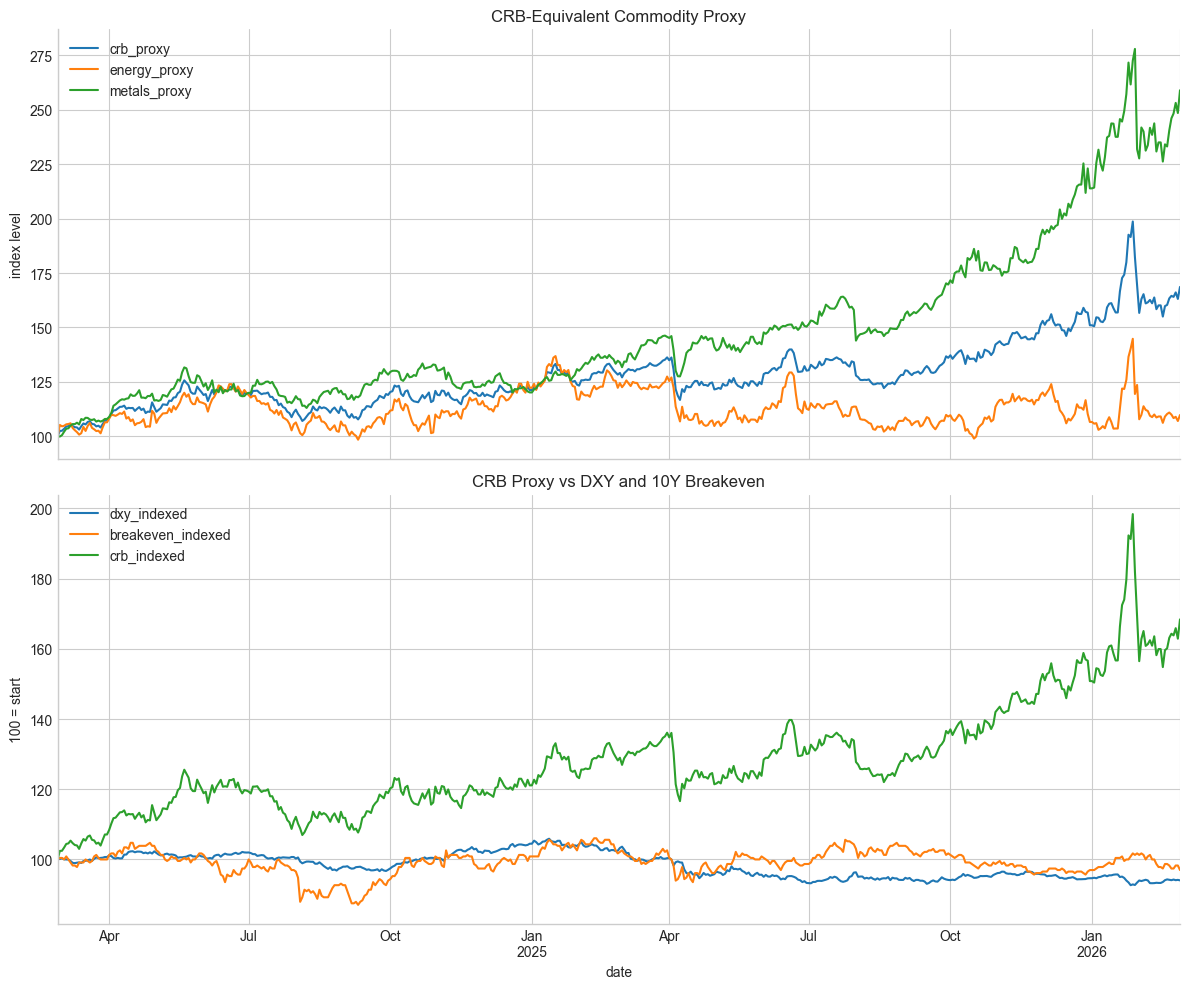

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

analysis_panel[["crb_proxy", "energy_proxy", "metals_proxy"]].plot(ax=axes[0], title="CRB-Equivalent Commodity Proxy")
axes[0].set_ylabel("index level")

comparison = pd.DataFrame(index=analysis_panel.index)
comparison["dxy_indexed"] = analysis_panel["DX-Y.NYB"] / analysis_panel["DX-Y.NYB"].iloc[0] * 100.0
comparison["breakeven_indexed"] = analysis_panel["T10YIE"] / analysis_panel["T10YIE"].iloc[0] * 100.0
comparison["crb_indexed"] = analysis_panel["crb_proxy"] / analysis_panel["crb_proxy"].iloc[0] * 100.0
comparison.plot(ax=axes[1], title="CRB Proxy vs DXY and 10Y Breakeven")
axes[1].set_ylabel("100 = start")

plt.tight_layout()
plt.show()


In [6]:
proxy_panel.to_csv(CRB_PROXY_CSV)
print("saved commodity proxy panel to", CRB_PROXY_CSV)
proxy_panel[["crb_proxy", "energy_proxy", "metals_proxy"]].tail()


saved commodity proxy panel to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-27_global_macro_trading_gliner/05_commodity_proxy_panel.csv


             crb_proxy  energy_proxy  metals_proxy
date                                              
2026-02-23  164.518347    110.032302    245.984915
2026-02-24  164.047080    108.424484    248.204496
2026-02-25  166.098975    109.014480    253.075275
2026-02-26  163.104673    107.082739    248.435320
2026-02-27  168.611888    109.825076    258.865917